In [6]:
# === Imports, configuración y utilidades ====================================
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np
import pandas as pd
from pathlib import Path
import joblib

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, recall_score

from interpret.glassbox import ExplainableBoostingClassifier

import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# outer_bags = nº de réplicas bagging del EBM. 8 = equilibrio coste/estabilidad.
# El MISMO valor en TODOS los modelos -> la comparación es válida.
OUTER_BAGS = 8

# Rutas absolutas (funciona abras el notebook desde donde lo abras) -----------
ROOT     = Path.cwd().parent
MODELDIR = ROOT / "modelos_domibm"; MODELDIR.mkdir(exist_ok=True)   # caché de modelos
FIGDIR   = ROOT / "figuras";        FIGDIR.mkdir(exist_ok=True)     # figuras

DATA = {}   # nombre -> dict(Xtr,Xte,ytr,yte,feats,domain_pairs,triplet,class_names)

# Utilidades
def maybe_subsample(X, y):
    return X, y   # (sin efecto; se conserva para no tocar las celdas de carga)

def njobs_for(tag):
    # Los modelos 'auto' lanzan FAST sobre TODOS los pares candidatos -> mucha
    # memoria; con 16 GB y n_jobs alto el SO mata el proceso. Se les baja el
    # paralelismo. NO cambia el resultado (determinista), solo memoria/velocidad.
    if tag.endswith('auto'):
        return 3 if tag.startswith('DS2OS') else 4
    return -2

def get_or_train(tag, interactions, feats, Xtr, ytr):
    """Carga el EBM si ya está en la caché; si no, lo entrena y lo guarda.
    Esto hace el notebook RESUME-SAFE: si el kernel se cae, al re-ejecutar
    recarga lo ya hecho y solo entrena lo que falte."""
    f = MODELDIR / f"ebm_{tag}.joblib"
    if f.exists():
        print(f"  [load ] {tag}")
        return joblib.load(f)
    t = time.time()
    m = ExplainableBoostingClassifier(
        feature_names=feats, interactions=interactions,
        outer_bags=OUTER_BAGS, n_jobs=njobs_for(tag), random_state=RANDOM_SEED)
    m.fit(Xtr, ytr)
    joblib.dump(m, f)
    print(f"  [train] {tag} en {time.time()-t:.0f}s -> guardado")
    return m

def names_to_idx(feats, groups):
    '''[('a','b'),...] -> [(idx_a,idx_b),...] segun el orden de columnas usado en fit.'''
    return [tuple(feats.index(f) for f in g) for g in groups]

def eval_ebm(m, Xte, yte):
    p = m.predict(Xte)
    return dict(
        f1_macro    = f1_score(yte, p, average='macro'),
        f1_weighted = f1_score(yte, p, average='weighted'),
        accuracy    = accuracy_score(yte, p),
        recall_macro= recall_score(yte, p, average='macro', zero_division=0),
    )

def auto_pairs_of(m, feats):
    '''Pares (2-way) que el EBM realmente incluye, como tuplas de nombres.'''
    return [tuple(feats[i] for i in tf) for tf in m.term_features_ if len(tf) == 2]

print(f'Configurado. OUTER_BAGS={OUTER_BAGS} | caché de modelos en {MODELDIR}')


Configurado. OUTER_BAGS=8 | caché de modelos en c:\Users\user\TFM\modelos_domibm


In [7]:
# === Carga NSL-KDD (preprocesamiento idéntico a EBM.ipynb) ===================
COL_NAMES = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty']
SELECTED_FEATURES = ['src_bytes','service','dst_bytes','flag','diff_srv_rate',
                     'same_srv_rate','dst_host_srv_count','dst_host_same_srv_rate']
CLASS_NAMES_NSL = {1:'Normal',2:'DoS',3:'Probe',4:'R2L',5:'U2R'}
DOS={'back','land','neptune','pod','smurf','teardrop','apache2','udpstorm','processtable','mailbomb'}
PROBE={'ipsweep','nmap','portsweep','satan','mscan','saint'}
R2L={'ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster',
     'sendmail','named','snmpgetattack','snmpguess','xlock','xsnoop','worm'}
U2R={'buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm'}
def map_label_nsl(l):
    l=l.lower().strip()
    if l=='normal': return 1
    if l in DOS: return 2
    if l in PROBE: return 3
    if l in R2L: return 4
    if l in U2R: return 5
    return 2

SEARCH_PATHS_NSL = [
    (Path.home() / ".cache" / "kagglehub" / "datasets" / "hassan06" / "nslkdd" / "versions" / "1" / "KDDTrain+_20Percent.txt"),
    Path("KDDTrain+_20Percent.txt"),
    Path.home()/"Downloads"/"KDDTrain+_20Percent.txt"]
ruta_nsl = next((p for p in SEARCH_PATHS_NSL if p.exists()), None)
assert ruta_nsl is not None, "No se encontró KDDTrain+_20Percent.txt"

df = pd.read_csv(ruta_nsl, header=None, names=COL_NAMES).drop(columns=['difficulty'])
df['service'] = LabelEncoder().fit_transform(df['service'].astype(str))
df['flag']    = LabelEncoder().fit_transform(df['flag'].astype(str))
y = df['label'].apply(map_label_nsl).values
X = df[SELECTED_FEATURES].values.astype(np.float32)
X, y = maybe_subsample(X, y)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20,
                                      random_state=RANDOM_SEED, stratify=y)
sc = MinMaxScaler(); Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)

DATA['NSL-KDD'] = dict(
    Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, feats=list(SELECTED_FEATURES),
    class_names=CLASS_NAMES_NSL,
    domain_pairs=[('flag','service'),
                  ('dst_host_srv_count','dst_host_same_srv_rate'),
                  ('same_srv_rate','diff_srv_rate')],
    triplet=('flag','service','dst_host_srv_count'))
print(f"NSL-KDD: train={len(Xtr):,} test={len(Xte):,} feats={len(SELECTED_FEATURES)}")


NSL-KDD: train=20,153 test=5,039 feats=8


In [8]:
# === Carga Mirai (preprocesamiento idéntico a EBM.ipynb) =====================
def reclassify_state_mirai(row):
    proto=row.get('state',row.get('proto','OTHER')); b=row.get('b_pkts',0); a=row.get('avg_pkt_size',0)
    if proto=='DNS': return 'DNS_FLOOD'
    if proto in ('HTTP','HTTPS'): return 'HTTP_FLOOD'
    if proto=='SSH': return 'OTHER'
    if proto=='UDP_OTHER':
        if b==0 and a<100: return 'UDP_SMALL_NORESPONSE'
        elif b==0: return 'UDP_LARGE_NORESPONSE'
        else: return 'UDP_BIDIRECTIONAL'
    if proto=='TCP_OTHER':
        if b==0 and a<80: return 'TCP_SYN_LIKE'
        elif b==0: return 'TCP_ACK_LIKE'
        else: return 'TCP_ESTABLISHED'
    return 'OTHER'
HWANG_CLASS_TOTAL = {'Normal':76725,'ACK_Flood':7425,'DNS_Flood':4851,'Mirai_CnC':76725,
    'GREIP_Flood':27801,'HTTP_Flood':135,'SYN_Flood':76725,'UDP_Flood':31878,'VSE_Flood':4986}
FEATURE_COLS_MIRAI = ['n_pkts','n_bytes','f_pkts','f_bytes','b_pkts','b_bytes','avg_pkt_size','duration','state']
CLASS_NAMES_MIRAI = list(HWANG_CLASS_TOTAL.keys())

def find_mirai_file():
    c = (Path.cwd().parent / "data" / "flows.csv")
    if c.exists(): return c
    for base in [Path('.'),Path.home()/'Downloads',Path.home()/'.cache',Path.home()/'markov_mirai']:
        for f in base.rglob('*.csv'):
            if any(k in f.name.lower() for k in ('mirai','hwang','flows')): return f
    raise FileNotFoundError("No se encontró flows.csv de Mirai")

ruta_mirai = find_mirai_file()
dfm = pd.read_csv(ruta_mirai)
if 'state' in dfm.columns:
    dfm['state'] = dfm.apply(reclassify_state_mirai, axis=1)
np.random.seed(RANDOM_SEED)
keep=[]
for cls,n in HWANG_CLASS_TOTAL.items():
    if 'class_name' not in dfm.columns: break
    idxc = np.where(dfm['class_name'].values==cls)[0]
    if len(idxc)==0: continue
    if len(idxc)>n: idxc = np.random.choice(idxc, n, replace=False)
    keep.append(idxc)
if keep:
    dfm = dfm.iloc[np.sort(np.concatenate(keep))].reset_index(drop=True)
dfm['state'] = LabelEncoder().fit_transform(dfm['state'].astype(str))
c2i = {c:i for i,c in enumerate(CLASS_NAMES_MIRAI)}
y = dfm['class_name'].map(c2i).values
feats_mirai = [f for f in FEATURE_COLS_MIRAI if f in dfm.columns]
X = dfm[feats_mirai].apply(pd.to_numeric, errors='coerce').fillna(0).values.astype(np.float32)
X, y = maybe_subsample(X, y)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20,
                                      random_state=RANDOM_SEED, stratify=y)
sc = MinMaxScaler(); Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)

DATA['Mirai'] = dict(
    Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, feats=list(feats_mirai),
    class_names={i:c for c,i in c2i.items()},
    domain_pairs=[('duration','n_pkts'),('f_pkts','b_pkts'),('b_pkts','avg_pkt_size')],
    triplet=('duration','f_pkts','b_pkts'))
print(f"Mirai: train={len(Xtr):,} test={len(Xte):,} feats={len(feats_mirai)}")


Mirai: train=129,107 test=32,277 feats=9


In [9]:
# === Carga DS2OS (preprocesamiento idéntico a EBM.ipynb) =====================
CLASS_MAP = {'normal':'Normal','anomalous(DoSattack)':'DoS','anomalous(scan)':'Scan',
    'anomalous(malitiousControl)':'MaliciousControl','anomalous(malitiousOperation)':'MaliciousOperation',
    'anomalous(spying)':'Spying','anomalous(dataProbing)':'DataProbing','anomalous(wrongSetUp)':'WrongSetUp'}
CLASS_TO_INT = {v:i for i,v in enumerate(CLASS_MAP.values())}
CAT_COLS_DS2OS = ['sourceID','sourceAddress','sourceType','sourceLocation',
    'destinationServiceAddress','destinationServiceType','destinationLocation',
    'accessedNodeAddress','accessedNodeType','operation']
FEAT_DS2OS = CAT_COLS_DS2OS + ['value']

SEARCH_PATHS_DS2OS = [Path("DS2OS.csv"), Path.home()/"Downloads"/"DS2OS.csv",
    (Path.home() / ".cache" / "kagglehub" / "datasets" / "libamariyam" / "ds2os-dataset" / "versions" / "1" / "DS2OS.csv")]
ruta_ds2os = next((p for p in SEARCH_PATHS_DS2OS if p.exists()), None)
assert ruta_ds2os is not None, "No se encontró DS2OS.csv"

dfd = pd.read_csv(ruta_ds2os)
dfd['accessedNodeType'] = dfd['accessedNodeType'].fillna('Malicious')
dfd['value'] = dfd['value'].replace({'False':0,'True':1,'Twenty':20,'none':0})
dfd['value'] = pd.to_numeric(dfd['value'], errors='coerce').fillna(0)
dfd = dfd.drop(columns=['timestamp'])
y = dfd['normality'].map(CLASS_MAP).map(CLASS_TO_INT).astype(np.int16).values
dfd = dfd.drop(columns=['normality'])
for col in CAT_COLS_DS2OS:
    dfd[col] = LabelEncoder().fit_transform(dfd[col].astype(str))
X = dfd[FEAT_DS2OS].values.astype(np.float32)
X, y = maybe_subsample(X, y)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20,
                                      random_state=RANDOM_SEED, stratify=y)
sc = StandardScaler(); Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)

DATA['DS2OS'] = dict(
    Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, feats=list(FEAT_DS2OS),
    class_names={i:c for c,i in CLASS_TO_INT.items()},
    domain_pairs=[('sourceAddress','accessedNodeAddress'),
                  ('sourceType','operation'),
                  ('sourceType','accessedNodeType')],
    triplet=('sourceType','accessedNodeType','operation'))
print(f"DS2OS: train={len(Xtr):,} test={len(Xte):,} feats={len(FEAT_DS2OS)}")


DS2OS: train=286,361 test=71,591 feats=11


## Estudio 1 — pares de dominio vs FAST vs sin interacciones





 NSL-KDD
  [load ] NSL-KDD_e1_main
    EBM-main    F1m=0.8764  F1w=0.9924  acc=0.9925
  [load ] NSL-KDD_e1_auto
    EBM-auto    F1m=0.8787  F1w=0.9942  acc=0.9942
  [load ] NSL-KDD_e1_domain
    EBM-domain  F1m=0.8746  F1w=0.9932  acc=0.9933
  FAST incluyó 10 pares | dominio∩FAST: ninguno


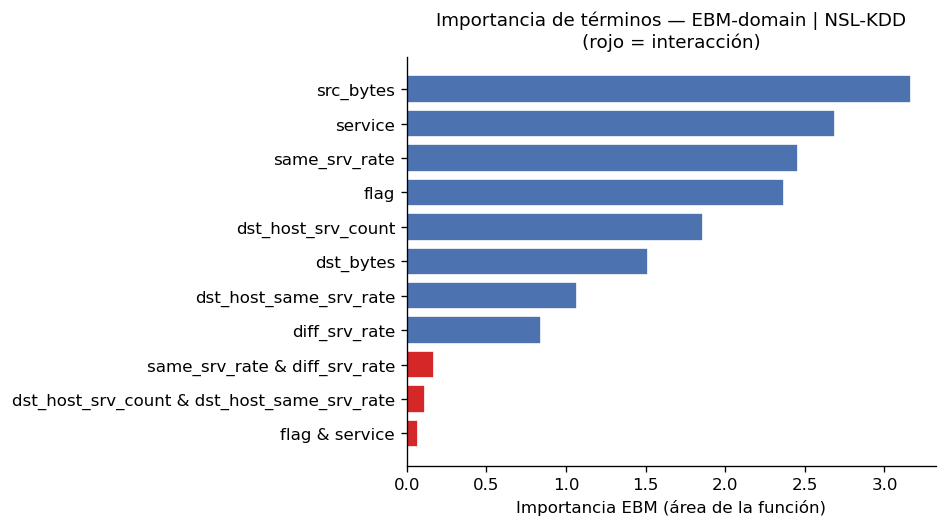

Figura: domibm_nslkdd_importancias.png

 Mirai
  [load ] Mirai_e1_main
    EBM-main    F1m=0.7629  F1w=0.9584  acc=0.9655
  [train] Mirai_e1_auto en 1845s -> guardado
    EBM-auto    F1m=0.7638  F1w=0.9585  acc=0.9656
  [train] Mirai_e1_domain en 1703s -> guardado
    EBM-domain  F1m=0.7639  F1w=0.9585  acc=0.9656
  FAST incluyó 10 pares | dominio∩FAST: [('f_pkts', 'b_pkts')]


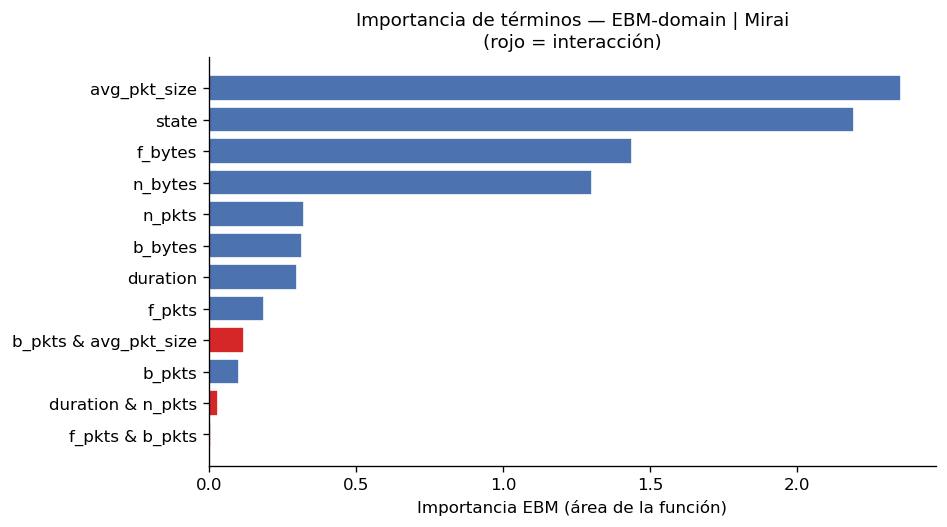

Figura: domibm_mirai_importancias.png

 DS2OS
  [train] DS2OS_e1_main en 214s -> guardado
    EBM-main    F1m=0.9488  F1w=0.9931  acc=0.9936
  [train] DS2OS_e1_auto en 4549s -> guardado
    EBM-auto    F1m=0.9532  F1w=0.9933  acc=0.9938
  [train] DS2OS_e1_domain en 3351s -> guardado
    EBM-domain  F1m=0.9573  F1w=0.9933  acc=0.9938
  FAST incluyó 10 pares | dominio∩FAST: ninguno


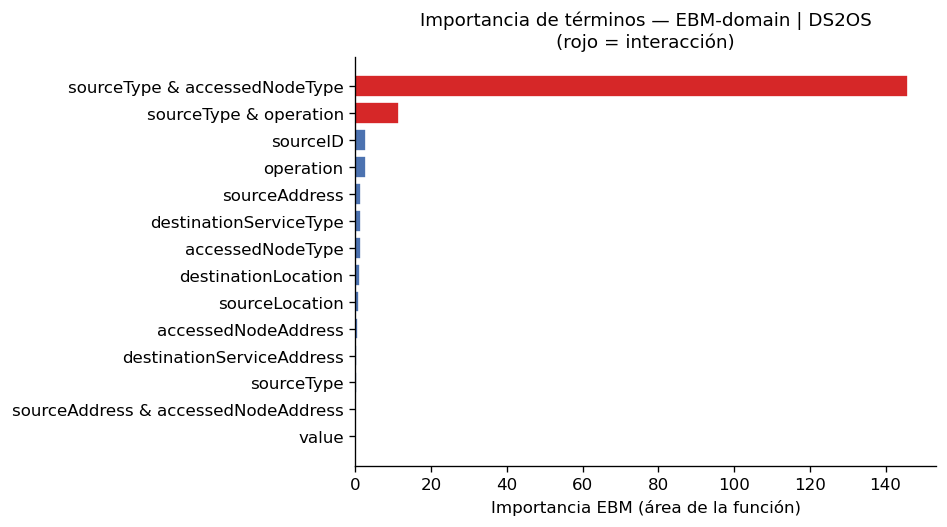

Figura: domibm_ds2os_importancias.png


In [10]:
# === Estudio 1: ejecución (carga de caché o entrena) =========================
def estudio1(nombre, d):
    feats = d['feats']
    configs = {'main': 0,
               'auto': 10,
               'domain': names_to_idx(feats, d['domain_pairs'])}
    res, fitted = {}, {}
    print(f"\n{'='*64}\n {nombre}\n{'='*64}")
    for key, inter in configs.items():
        m = get_or_train(f"{nombre}_e1_{key}", inter, feats, d['Xtr'], d['ytr'])
        r = eval_ebm(m, d['Xte'], d['yte'])
        res[f'EBM-{key}'] = r; fitted[key] = m
        print(f"    EBM-{key:7} F1m={r['f1_macro']:.4f}  F1w={r['f1_weighted']:.4f}  "
              f"acc={r['accuracy']:.4f}")
    fast = set(frozenset(p) for p in auto_pairs_of(fitted['auto'], feats))
    dom  = set(frozenset(p) for p in d['domain_pairs'])
    solap = [tuple(x) for x in (dom & fast)]
    print(f"  FAST incluyó {len(fast)} pares | dominio∩FAST: {solap if solap else 'ninguno'}")
    return res, fitted

def plot_importancias(nombre, m, feats):
    names = list(m.term_names_); imp = m.term_importances()
    order = np.argsort(imp)[::-1][:15]
    es_int = [' & ' in names[i] for i in order]
    cols = ['#d62728' if e else '#4C72B0' for e in es_int]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh([names[i] for i in order][::-1], [imp[i] for i in order][::-1],
            color=cols[::-1], edgecolor='white')
    ax.set_title(f'Importancia de términos — EBM-domain | {nombre}\n(rojo = interacción)', fontsize=11)
    ax.set_xlabel('Importancia EBM (área de la función)')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    f = FIGDIR / f"domibm_{nombre.lower().replace('-','')}_importancias.png"
    plt.savefig(f, dpi=140, bbox_inches='tight'); plt.show()
    print('Figura:', f.name)

RES1, FIT1 = {}, {}
for nombre, d in DATA.items():
    RES1[nombre], FIT1[nombre] = estudio1(nombre, d)
    plot_importancias(nombre, FIT1[nombre]['domain'], d['feats'])


In [11]:
# === Estudio 1: tabla comparativa (impresa) =================================
filas = []
for nombre, res in RES1.items():
    for modelo, r in res.items():
        filas.append(dict(dataset=nombre, modelo=modelo,
                          f1_macro=round(r['f1_macro'],4),
                          f1_weighted=round(r['f1_weighted'],4),
                          accuracy=round(r['accuracy'],4),
                          recall_macro=round(r['recall_macro'],4)))
tabla1 = pd.DataFrame(filas).set_index(['dataset','modelo'])
print('='*70)
print(' ESTUDIO 1 - EBM-main / EBM-auto (FAST) / EBM-domain')
print(' F1-weighted y accuracy salen ~iguales (clases mayoritarias);')
print(' lo que DISCRIMINA es F1-macro / recall-macro (clases minoritarias).')
print('='*70)
print(tabla1.to_string())


 ESTUDIO 1 - EBM-main / EBM-auto (FAST) / EBM-domain
 F1-weighted y accuracy salen ~iguales (clases mayoritarias);
 lo que DISCRIMINA es F1-macro / recall-macro (clases minoritarias).
                    f1_macro  f1_weighted  accuracy  recall_macro
dataset modelo                                                   
NSL-KDD EBM-main      0.8764       0.9924    0.9925        0.8651
        EBM-auto      0.8787       0.9942    0.9942        0.8727
        EBM-domain    0.8746       0.9932    0.9933        0.8618
Mirai   EBM-main      0.7629       0.9584    0.9655        0.7615
        EBM-auto      0.7638       0.9585    0.9656        0.7618
        EBM-domain    0.7639       0.9585    0.9656        0.7618
DS2OS   EBM-main      0.9488       0.9931    0.9936        0.9257
        EBM-auto      0.9532       0.9933    0.9938        0.9301
        EBM-domain    0.9573       0.9933    0.9938        0.9416


## Estudio 2 — ¿aporta un grupo de 3?




In [12]:
# === Estudio 2: ablación 3-way (carga de caché o entrena) ====================
def estudio2(nombre, d):
    feats = d['feats']; a, b, c = d['triplet']
    subs = [(a,b),(a,c),(b,c)]
    modelos = {'P3': names_to_idx(feats, subs),
               'T3': names_to_idx(feats, subs + [(a,b,c)])}
    res = {}
    print(f"\n{'='*64}\n {nombre} — trío ({a} × {b} × {c})\n{'='*64}")
    for key, inter in modelos.items():
        m = get_or_train(f"{nombre}_e2_{key}", inter, feats, d['Xtr'], d['ytr'])
        r = eval_ebm(m, d['Xte'], d['yte']); res[key] = r
        print(f"    {key} F1m={r['f1_macro']:.4f}  F1w={r['f1_weighted']:.4f}  "
              f"acc={r['accuracy']:.4f}")
    delta = res['T3']['f1_macro'] - res['P3']['f1_macro']
    res['delta_f1_macro'] = round(delta, 4)
    print(f"  Δ 3er orden (T3 − P3) en F1-macro = {delta:+.4f}")
    return res

RES2 = {nombre: estudio2(nombre, d) for nombre, d in DATA.items()}



 NSL-KDD — trío (flag × service × dst_host_srv_count)
  [train] NSL-KDD_e2_P3 en 123s -> guardado
    P3 F1m=0.8744  F1w=0.9930  acc=0.9931
  [train] NSL-KDD_e2_T3 en 159s -> guardado
    T3 F1m=0.8745  F1w=0.9932  acc=0.9933
  Δ 3er orden (T3 − P3) en F1-macro = +0.0001

 Mirai — trío (duration × f_pkts × b_pkts)
  [train] Mirai_e2_P3 en 1684s -> guardado
    P3 F1m=0.7635  F1w=0.9585  acc=0.9657
  [train] Mirai_e2_T3 en 2872s -> guardado
    T3 F1m=0.7635  F1w=0.9585  acc=0.9657
  Δ 3er orden (T3 − P3) en F1-macro = -0.0000

 DS2OS — trío (sourceType × accessedNodeType × operation)
  [train] DS2OS_e2_P3 en 2497s -> guardado
    P3 F1m=0.9596  F1w=0.9934  acc=0.9939
  [train] DS2OS_e2_T3 en 3924s -> guardado
    T3 F1m=0.9619  F1w=0.9935  acc=0.9940
  Δ 3er orden (T3 − P3) en F1-macro = +0.0023


In [13]:
# === Estudio 2: tabla y conclusion (impresa) ================================
filas = []
for nombre, res in RES2.items():
    filas.append(dict(dataset=nombre,
                      P3_f1_macro=round(res['P3']['f1_macro'],4),
                      T3_f1_macro=round(res['T3']['f1_macro'],4),
                      delta_3er_orden=res['delta_f1_macro']))
tabla2 = pd.DataFrame(filas).set_index('dataset')
print('='*70)
print(' ESTUDIO 2 - ablacion 3-way   (Delta = T3 - P3 = aporte puro del 3er orden)')
print('='*70)
print(tabla2.to_string())
print('\nLectura: Delta~0 -> el 3er orden no compensa su coste de explicabilidad'
      '\n(un trio ya no es un heatmap 2D legible) -> el optimo coste/auditabilidad es 2-way.')


 ESTUDIO 2 - ablacion 3-way   (Delta = T3 - P3 = aporte puro del 3er orden)
         P3_f1_macro  T3_f1_macro  delta_3er_orden
dataset                                           
NSL-KDD       0.8744       0.8745           0.0001
Mirai         0.7635       0.7635          -0.0000
DS2OS         0.9596       0.9619           0.0023

Lectura: Delta~0 -> el 3er orden no compensa su coste de explicabilidad
(un trio ya no es un heatmap 2D legible) -> el optimo coste/auditabilidad es 2-way.
